# 02 — Análise de Resultados dos Modelos

Este notebook **não re-treina os modelos**. Ele carrega os artefatos já gerados pelo script `src/train.py` e apresenta os resultados de forma visual e analítica.

**Pré-requisito:** rode `python src/train.py` na raiz do projeto antes de executar este notebook.

---

O pipeline de treinamento avalia três modelos com **ajuste automático de hiperparâmetros via GridSearchCV** (validação cruzada de 5 folds):
- **Logistic Regression** — modelo linear probabilístico
- **Random Forest** — ensemble de árvores de decisão
- **SVM** — busca o hiperplano de máxima margem entre as classes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Comparação de desempenho entre os modelos

O arquivo `reports/model_comparison.csv` é gerado automaticamente pelo `train.py` e contém as métricas de cada modelo:

- **accuracy** — porcentagem de acertos no conjunto de teste
- **auc** — área sob a curva ROC (1.0 = perfeito, 0.5 = aleatório)
- **cv_mean** — média de acurácia nas 5 rodadas do GridSearchCV
- **cv_std** — desvio padrão entre as rodadas (menor = mais estável)
- **best_params** — melhores hiperparâmetros encontrados automaticamente

In [2]:
results_df = pd.read_csv("../reports/model_comparison.csv")
results_df.style.format({
    "accuracy": "{:.2%}",
    "auc": "{:.4f}",
    "cv_mean": "{:.2%}",
    "cv_std": "{:.4f}",
}).background_gradient(subset=["accuracy", "auc", "cv_mean"], cmap="Greens")

,model,accuracy,auc,cv_mean,cv_std,best_params
0,svm,98.25%,0.9937,97.80%,0.0139,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}"
1,logistic_regression,97.37%,0.9957,98.02%,0.0162,"{'model__C': 0.1, 'model__solver': 'lbfgs'}"
2,random_forest,95.61%,0.9931,96.04%,0.0192,"{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}"


## Curvas ROC

A **curva ROC** (Receiver Operating Characteristic) mostra o desempenho do modelo em todos os possíveis limiares de decisão. O eixo X representa a taxa de falsos positivos e o eixo Y a taxa de verdadeiros positivos (sensibilidade).

A **AUC** (área sob a curva) resume esse desempenho em um único número: quanto mais próxima de 1.0, melhor o modelo consegue separar as classes.

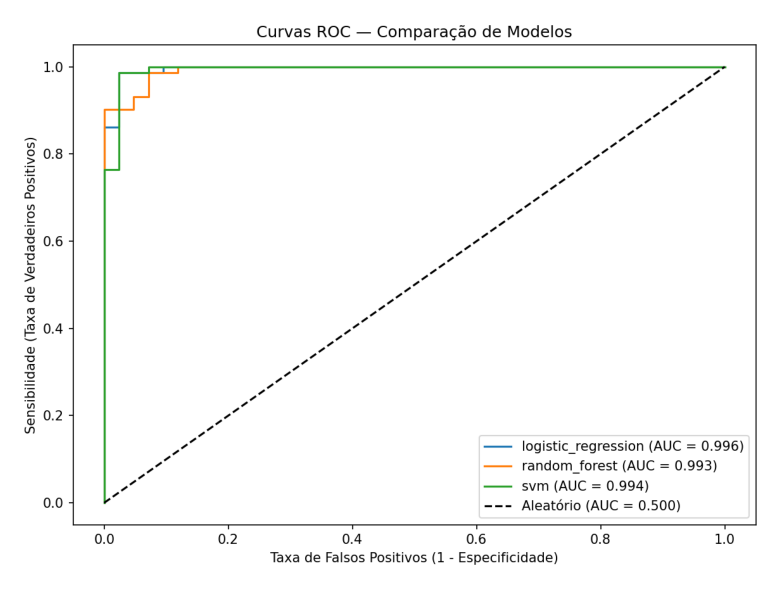

In [3]:
img = mpimg.imread("../figures/roc_curves.png")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

## Feature Importance

### Random Forest
A Random Forest calcula automaticamente a **importância de cada feature** com base em quanto ela contribuiu para reduzir a incerteza nas decisões das 200 árvores. Features usadas no topo das árvores e com maior frequência recebem maior pontuação.

### Regressão Logística
Os **coeficientes** da Regressão Logística indicam o peso de cada feature na decisão final. Coeficientes negativos empurram a predição para maligno; positivos, para benigno. Como os dados foram normalizados antes do treino, os coeficientes são comparáveis entre si.

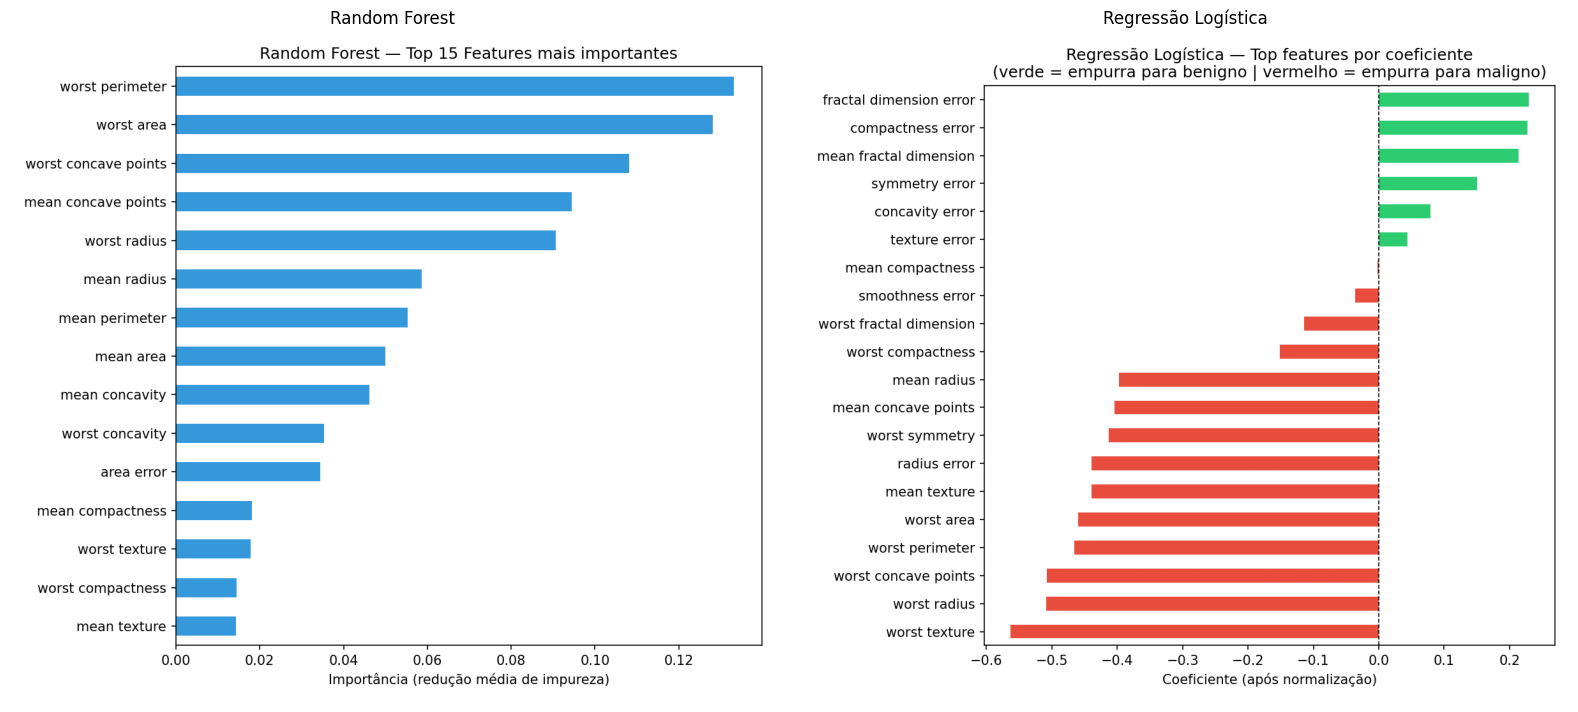

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, fname, title in [
    (axes[0], "../figures/feature_importance_rf.png", "Random Forest"),
    (axes[1], "../figures/feature_importance_lr.png", "Regressão Logística"),
]:
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

## Curva de Aprendizado

A curva de aprendizado mostra como a acurácia do melhor modelo evolui conforme aumentamos o tamanho do conjunto de treinamento — de 10% até 100% dos dados disponíveis.

Ela responde uma pergunta prática fundamental: **se eu tivesse mais dados clínicos, o modelo melhoraria significativamente?**

- **Linha azul (treino):** acurácia no próprio conjunto de treino
- **Linha vermelha (validação):** acurácia média em validação cruzada (dados que o modelo não viu)
- **Faixa sombreada:** desvio padrão entre as rodadas de validação

Se as duas curvas convergem em valores altos, o modelo está saturado para este dataset — mais dados teriam retorno marginal.

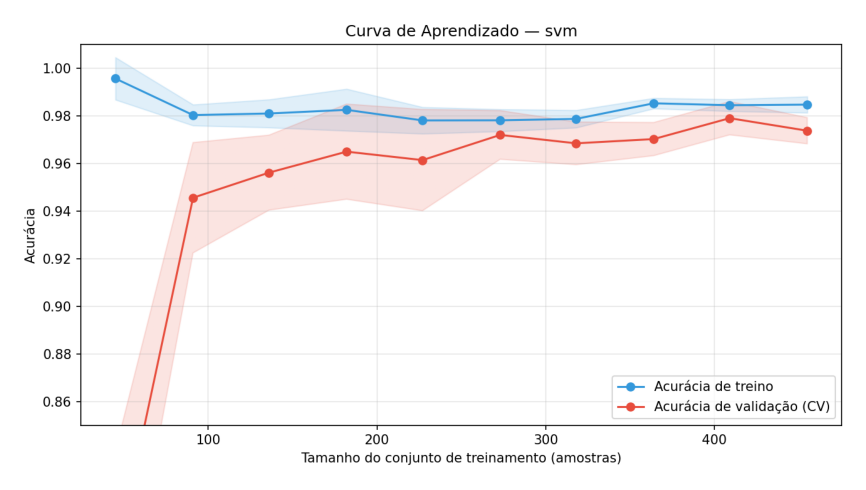

In [5]:
img = mpimg.imread("../figures/learning_curve.png")
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

## Explicabilidade com SHAP

**SHAP** (SHapley Additive exPlanations) vai além da importância global de features — ele calcula a contribuição de cada feature para **cada predição individual**.

Enquanto o gráfico de feature importance diz "worst concave points é importante globalmente", o SHAP diz: "para *este tumor específico*, worst concave points aumentou a probabilidade de malignidade em +0.18".

### Beeswarm Plot — visão global
Cada ponto é uma amostra. A posição no eixo X mostra o impacto SHAP (positivo = empurra para maligno). A cor indica o valor da feature (vermelho = alto, azul = baixo). Lendo o gráfico: features no topo com pontos vermelhos à direita são as que mais indicam malignidade quando têm valores altos.

> Nota: SHAP é calculado sobre o Random Forest, pois o TreeExplainer permite cálculo exato e eficiente. Para SVMs seria necessário usar KernelExplainer, uma aproximação significativamente mais lenta.

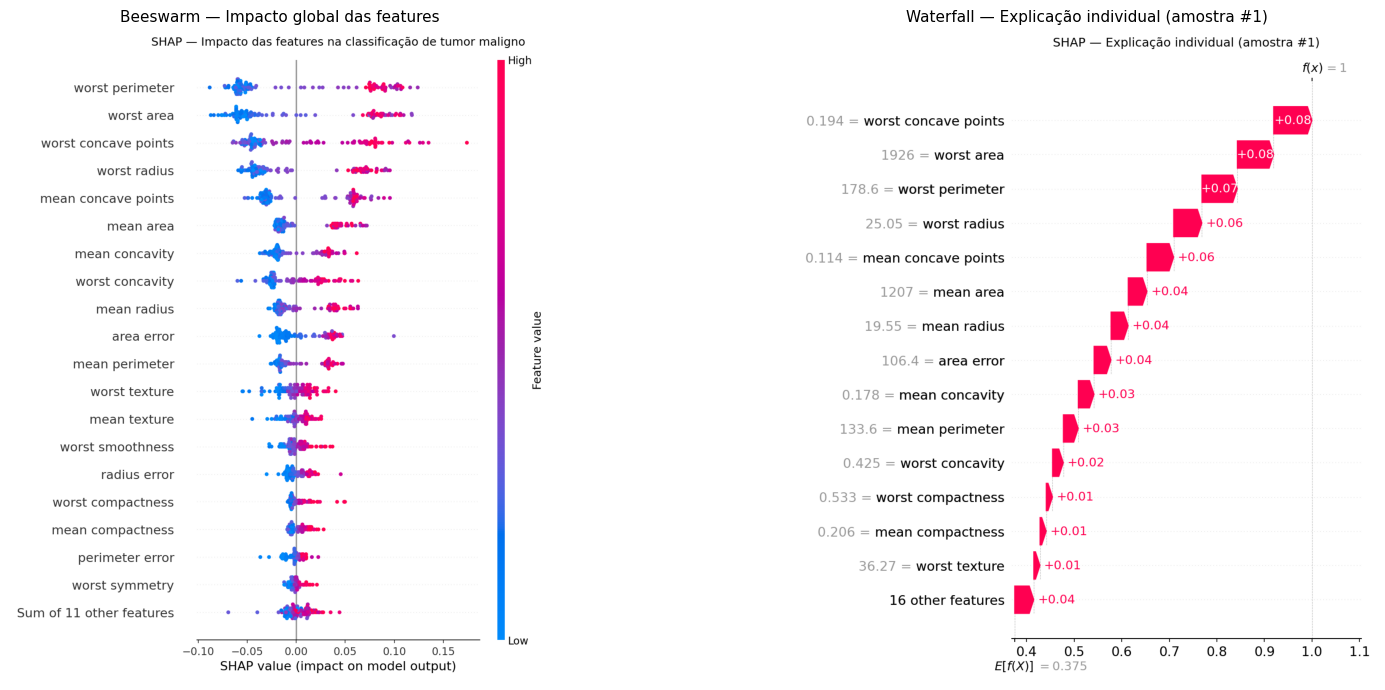

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, fname, title in [
    (axes[0], "../figures/shap_beeswarm.png", "Beeswarm — Impacto global das features"),
    (axes[1], "../figures/shap_waterfall.png", "Waterfall — Explicação individual (amostra #1)"),
]:
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

## Conclusão

Com base em todos os resultados:

- **SVM com kernel linear** foi o melhor modelo após otimização de hiperparâmetros via GridSearchCV: acurácia de **98.2%**, AUC de **0.994**. O GridSearchCV revelou que um kernel linear supera o RBF neste dataset — consistente com a alta separabilidade linear observada na análise exploratória.
- A **Regressão Logística** atingiu AUC ligeiramente superior (0.996), mas ficou abaixo em acurácia no teste (97.4%).
- O **Random Forest** ficou abaixo dos dois, o que era esperado para um dataset linearmente separável.

A **curva de aprendizado** mostra que as curvas de treino e validação convergem próximas a 100% dos dados, indicando que o modelo está saturado para este dataset — mais dados clínicos teriam retorno marginal, e o foco de melhoria deve ser a qualidade das features, não o volume.

A análise **SHAP** confirmou o que a correlação já sugeria: as features mais determinantes para o diagnóstico são `worst concave points`, `worst perimeter` e `worst radius` — todas relacionadas à forma e tamanho do pior núcleo observado, o que tem correspondência direta com o conhecimento clínico sobre morfologia de células malignas.